# Chapter 132 — Geometric Meaning of Dot Product

> **Prerequisites:** ch131 (dot product intuition), ch128 (norms), ch112 (trigonometry/unit circle)  
> **You will learn:**
> - Why $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$
> - How to derive this from the law of cosines
> - How the sign of the dot product tells you which half-space a vector lives in
> - How to extract angles from vectors using the dot product
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In ch131, we defined the dot product algebraically: $\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$. We observed that it behaves like an alignment score. This chapter proves why.

The geometric formula is:

$$\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \, \|\mathbf{b}\| \cos\theta$$

where $\theta \in [0, \pi]$ is the angle between the two vectors.

This connects three things: the sizes of the two vectors, the angle between them, and the scalar output. None of these alone determines the dot product — all three together do.

**Common misconceptions:**
- The formula gives $\theta \in [0, \pi]$ (0 to 180 degrees), not the full circle. Vectors do not have a signed direction of rotation between them.
- When $\mathbf{a}$ or $\mathbf{b}$ is the zero vector, the angle is undefined. The dot product is zero, but not because of orthogonality.

## 2. Intuition & Mental Models

**Physical:** A solar panel generates maximum power when it faces the sun directly ($\theta = 0$, $\cos\theta = 1$). Tilted at 90 degrees it generates nothing ($\cos\theta = 0$). Facing away, it generates negative (relative) contribution ($\cos\theta = -1$). The dot product is the formula for this.

**Geometric:** Think of the dot product as: *how much of $\mathbf{b}$ would I measure if I used $\mathbf{a}$'s direction as my ruler?* The answer is $\|\mathbf{b}\| \cos\theta$ — the signed projection length — scaled by $\|\mathbf{a}\|$. *(Projection formalized in ch134.)*

**Computational:** The formula $\cos\theta = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$ is how machines measure similarity. Divide out the magnitudes and you get a scale-free angle measure — cosine similarity. This is used in every search engine and recommendation system.

Recall from ch112 (Sine and Cosine) that $\cos\theta$ oscillates between $-1$ and $1$, peaking at $\theta=0$ and reaching $-1$ at $\theta=\pi$. The dot product inherits this shape exactly.

## 3. Visualization

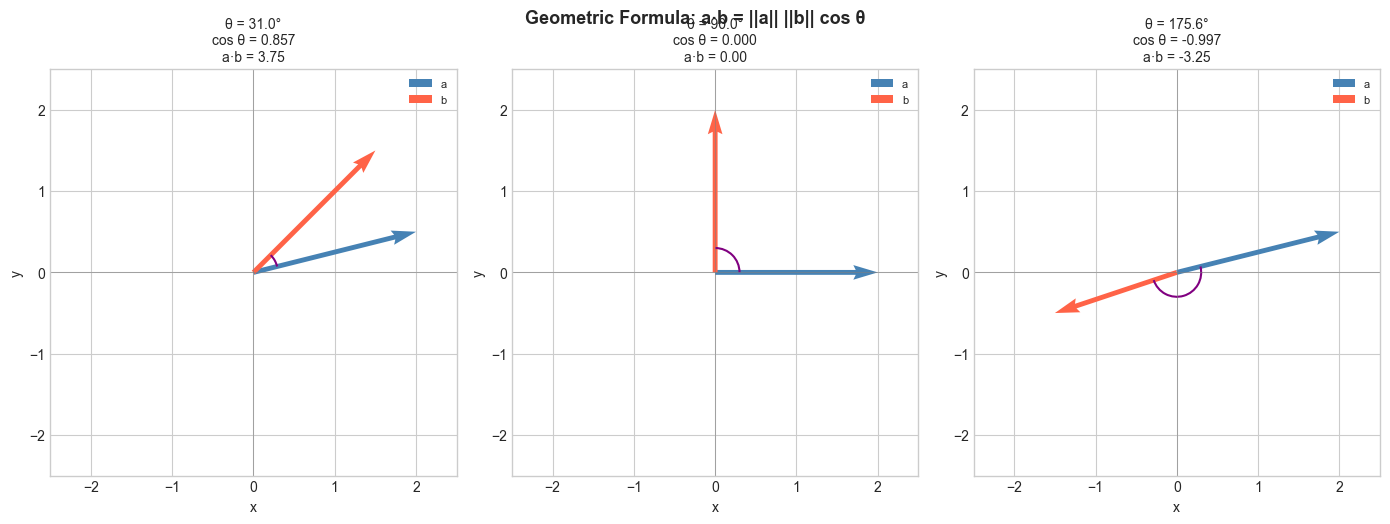

In [1]:
# --- Visualization: Angle between vectors and dot product formula ---

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

def draw_angle_arc(ax, v1, v2, radius=0.3, color='purple'):
    """Draw a small arc showing the angle between two vectors from origin."""
    angle1 = np.degrees(np.arctan2(v1[1], v1[0]))
    angle2 = np.degrees(np.arctan2(v2[1], v2[0]))
    if angle1 > angle2:
        angle1, angle2 = angle2, angle1
    arc = mpatches.Arc([0, 0], 2*radius, 2*radius,
                        angle=0, theta1=angle1, theta2=angle2,
                        color=color, linewidth=1.5)
    ax.add_patch(arc)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

test_cases = [
    (np.array([2.0, 0.5]), np.array([1.5, 1.5])),
    (np.array([2.0, 0.0]), np.array([0.0, 2.0])),
    (np.array([2.0, 0.5]), np.array([-1.5, -0.5])),
]

ORIGIN = np.array([0, 0])

for ax, (a, b) in zip(axes, test_cases):
    dot = np.dot(a, b)
    cos_theta = dot / (np.linalg.norm(a) * np.linalg.norm(b))
    theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

    ax.quiver(*ORIGIN, *a, angles='xy', scale_units='xy', scale=1,
               color='steelblue', width=0.012, label='a')
    ax.quiver(*ORIGIN, *b, angles='xy', scale_units='xy', scale=1,
               color='tomato', width=0.012, label='b')
    draw_angle_arc(ax, a, b)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_title(
        f'θ = {theta_deg:.1f}°\ncos θ = {cos_theta:.3f}\na·b = {dot:.2f}',
        fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Geometric Formula: a·b = ||a|| ||b|| cos θ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

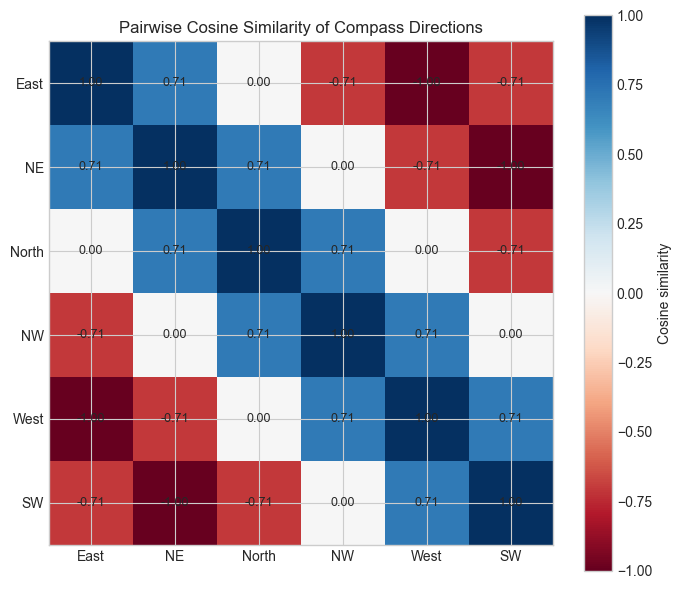

In [2]:
# --- Visualization: Cosine similarity heatmap ---
# Create several named vectors, compute all pairwise cosine similarities.

labels = ['East', 'NE', 'North', 'NW', 'West', 'SW']
angles_deg_map = [0, 45, 90, 135, 180, 225]
vectors = np.array([[np.cos(np.radians(a)), np.sin(np.radians(a))]
                     for a in angles_deg_map])

# Compute pairwise cosine similarities
n = len(vectors)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dot = np.dot(vectors[i], vectors[j])
        norms = np.linalg.norm(vectors[i]) * np.linalg.norm(vectors[j])
        sim_matrix[i, j] = dot / norms

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Pairwise Cosine Similarity of Compass Directions')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

### Derivation via the Law of Cosines

Consider vectors $\mathbf{a}$ and $\mathbf{b}$ and the vector $\mathbf{c} = \mathbf{a} - \mathbf{b}$, forming a triangle.

The **law of cosines** states:
$$\|\mathbf{c}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

Expand $\|\mathbf{c}\|^2 = \|\mathbf{a} - \mathbf{b}\|^2$ using dot product properties *(from the Hard exercise in ch131)*:

$$\|\mathbf{a} - \mathbf{b}\|^2 = \|\mathbf{a}\|^2 - 2(\mathbf{a}\cdot\mathbf{b}) + \|\mathbf{b}\|^2$$

Setting equal:
$$\|\mathbf{a}\|^2 - 2(\mathbf{a}\cdot\mathbf{b}) + \|\mathbf{b}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

Cancel and solve:
$$\boxed{\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta}$$

**Rearranged as the angle formula:**
$$\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}, \qquad \theta = \arccos\left(\frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}\right)$$

**Cosine similarity** (scale-free version):
$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|} \in [-1, 1]$$

## 5. Python Implementation

In [3]:
# --- Implementation: angle_between and cosine_similarity ---

def angle_between(a, b, degrees=False):
    """
    Compute the angle between two non-zero vectors.

    Args:
        a, b:    array-like, shape (n,), must be non-zero
        degrees: if True, return angle in degrees; else radians

    Returns:
        float: angle in [0, π] radians (or [0, 180] degrees)
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    # Clip to [-1, 1] to guard against floating point errors like cos=1.0000000002
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return np.degrees(theta) if degrees else theta


def cosine_similarity(a, b):
    """
    Scale-free similarity measure between two vectors.

    Returns:
        float in [-1, 1]; 1 = identical direction, -1 = opposite
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Test cases
print("Angle tests:")
print(f"  [1,0] vs [1,0]:  {angle_between([1,0],[1,0], degrees=True):.1f}°  (expect 0)")
print(f"  [1,0] vs [0,1]:  {angle_between([1,0],[0,1], degrees=True):.1f}°  (expect 90)")
print(f"  [1,0] vs [-1,0]: {angle_between([1,0],[-1,0], degrees=True):.1f}° (expect 180)")
print(f"  [1,1] vs [1,0]:  {angle_between([1,1],[1,0], degrees=True):.1f}°  (expect 45)")

print("\nCosine similarity tests:")
print(f"  [1,2,3] vs [2,4,6]: {cosine_similarity([1,2,3],[2,4,6]):.4f}  (expect 1.0 — same direction)")
print(f"  [1,0]   vs [0,1]:   {cosine_similarity([1,0],[0,1]):.4f}  (expect 0.0 — orthogonal)")

Angle tests:
  [1,0] vs [1,0]:  0.0°  (expect 0)
  [1,0] vs [0,1]:  90.0°  (expect 90)
  [1,0] vs [-1,0]: 180.0° (expect 180)
  [1,1] vs [1,0]:  45.0°  (expect 45)

Cosine similarity tests:
  [1,2,3] vs [2,4,6]: 1.0000  (expect 1.0 — same direction)
  [1,0]   vs [0,1]:   0.0000  (expect 0.0 — orthogonal)


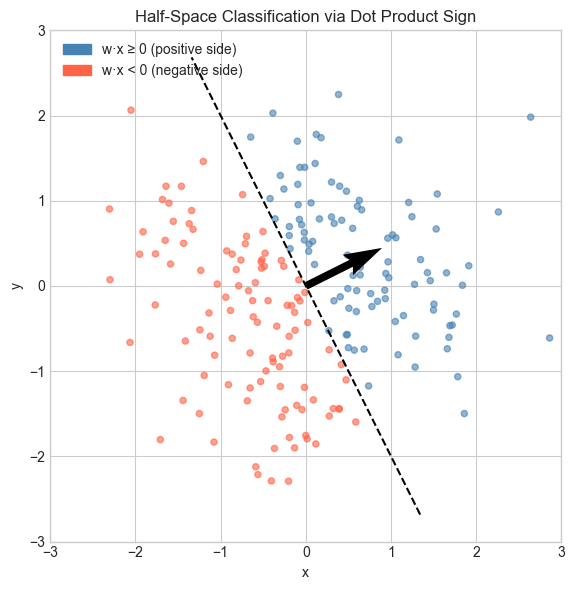

In [4]:
# --- Half-space classifier using dot product sign ---
# Given a direction vector w, classify points as positive/negative
# based on which side of the hyperplane through the origin they lie on.
# This is the geometric foundation of the perceptron (ch176).

np.random.seed(7)
N = 200
points = np.random.randn(N, 2)  # random 2D points

w = np.array([1.0, 0.5])  # decision direction vector
w_hat = w / np.linalg.norm(w)  # normalize for display

# Sign of dot product with w determines class
scores = points @ w  # dot product of each point with w
labels = (scores >= 0).astype(int)  # 1 if positive side, 0 if negative

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['tomato' if l == 0 else 'steelblue' for l in labels]
ax.scatter(points[:, 0], points[:, 1], c=colors, alpha=0.6, s=20)

# Draw the decision boundary (perpendicular to w, through origin)
t = np.linspace(-3, 3, 100)
boundary = np.array([-w[1], w[0]])  # perpendicular to w
boundary /= np.linalg.norm(boundary)
ax.plot(t * boundary[0], t * boundary[1], 'k--', linewidth=1.5, label='Decision boundary')

# Draw w
ax.quiver(0, 0, w_hat[0], w_hat[1], angles='xy', scale_units='xy', scale=1,
           color='black', width=0.015, label=f'w = {w}')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='w·x ≥ 0 (positive side)'),
    Patch(color='tomato',    label='w·x < 0 (negative side)'),
], loc='upper left')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_title('Half-Space Classification via Dot Product Sign')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## 6. Experiments

In [5]:
# --- Experiment 1: Verify the formula numerically ---
# Hypothesis: algebraic dot product equals ||a||*||b||*cos(theta) for any vectors.
# Try changing: N_DIMS and the random seed.

np.random.seed(42)
N_DIMS = 5  # <-- modify this

a = np.random.randn(N_DIMS)
b = np.random.randn(N_DIMS)

algebraic  = np.dot(a, b)
geometric  = np.linalg.norm(a) * np.linalg.norm(b) * np.cos(angle_between(a, b))

print(f"Algebraic  a·b = {algebraic:.8f}")
print(f"Geometric  a·b = {geometric:.8f}")
print(f"Difference:     {abs(algebraic - geometric):.2e}  (floating point error only)")

Algebraic  a·b = -0.67965499
Geometric  a·b = -0.67965499
Difference:     0.00e+00  (floating point error only)


In [ ]:
# --- Experiment 2: Cosine similarity vs raw dot product ---
# Hypothesis: two vectors pointing in the same direction have cosine sim = 1,
#             regardless of their magnitudes.
# Try changing: SCALE

a = np.array([1.0, 2.0, 3.0])
SCALE = 100.0  # <-- modify this
b = SCALE * a   # same direction, different magnitude

print(f"a = {a}")
print(f"b = SCALE * a = {b}")
print(f"Raw dot product:     {np.dot(a, b):.2f}  (grows with SCALE)")
print(f"Cosine similarity:   {cosine_similarity(a, b):.6f}  (always 1.0)")
print(f"Angle between them:  {angle_between(a, b, degrees=True):.6f}°  (always 0)")

In [6]:
# --- Experiment 3: Cosine similarity in NLP word space ---
# Simulate word embeddings. Find which word is most similar to a target.
# Try changing: TARGET_WORD and embedding dimension DIM.

np.random.seed(0)
words = ['cat', 'dog', 'fish', 'car', 'truck', 'road', 'kitten', 'puppy']
DIM = 10  # <-- modify this

# Random embeddings (in real NLP these are trained)
# Force 'cat' and 'kitten' to be similar
embeddings = {w: np.random.randn(DIM) for w in words}
embeddings['kitten'] = embeddings['cat'] + 0.3 * np.random.randn(DIM)
embeddings['puppy']  = embeddings['dog']  + 0.3 * np.random.randn(DIM)

TARGET_WORD = 'cat'  # <-- modify this
target = embeddings[TARGET_WORD]

print(f"Most similar to '{TARGET_WORD}':")
sims = {w: cosine_similarity(target, v) for w, v in embeddings.items() if w != TARGET_WORD}
for w, s in sorted(sims.items(), key=lambda x: -x[1]):
    print(f"  {w:10s}: {s:.4f}")

Most similar to 'cat':
  kitten    : 0.9568
  puppy     : 0.3760
  dog       : 0.3592
  fish      : 0.0649
  truck     : -0.0982
  car       : -0.4335
  road      : -0.7179


## 7. Exercises

**Easy 1.** Compute the angle between $[1, 0, 0]$ and $[1, 1, 0]$ using `angle_between`. Then verify geometrically. *(Expected: 45 degrees)*

**Easy 2.** Two vectors have magnitudes 3 and 5 and an angle of 60 degrees between them. What is their dot product? *(Expected: compute from formula without knowing the components)*

**Medium 1.** Write a function `pairwise_cosine(X)` that computes the full $n \times n$ cosine similarity matrix for a batch of $n$ vectors (shape `n×d`). Use matrix operations only — no Python loops. *(Hint: normalize rows first, then compute $XX^T$)*

**Medium 2.** Plot the angle between two randomly generated vectors as you linearly interpolate one toward the other: $\mathbf{b}(t) = (1-t)\mathbf{b}_0 + t\mathbf{a}$ for $t \in [0, 1]$. How does the angle change — linearly, or not? *(Hint: the angle is not a linear function of the interpolation parameter)*

**Hard.** Prove that for unit vectors $\hat{\mathbf{a}}, \hat{\mathbf{b}}$, we have $\|\hat{\mathbf{a}} - \hat{\mathbf{b}}\|^2 = 2(1 - \cos\theta)$. Use this to write an alternative angle computation that avoids `arccos`. When would this be numerically preferable? *(Challenge: think about what happens near $\theta \approx 0$)*

## 8. Mini Project — Semantic Search Engine

In [ ]:
# --- Mini Project: Cosine Similarity Search ---
# Problem: Given a set of document embeddings and a query embedding,
#          return the top-k most similar documents using cosine similarity.
# Dataset: Synthetic 50-dimensional embeddings.
# Task: Implement the search function and analyze the angle distribution.

np.random.seed(123)
N_DOCS = 100
DIM    = 50
TOP_K  = 5

# Simulate document embeddings
doc_embeddings = np.random.randn(N_DOCS, DIM)

# Create a query as a noisy version of document 0
query_embedding = doc_embeddings[0] + 0.5 * np.random.randn(DIM)

doc_labels = [f'Document {i}' for i in range(N_DOCS)]

def semantic_search(query, documents, top_k=5):
    """
    Find top-k most similar documents to query using cosine similarity.

    Args:
        query:     array (d,)
        documents: array (n, d)
        top_k:     int

    Returns:
        indices: array (top_k,), indices of best matches
        scores:  array (top_k,), cosine similarity scores
    """
    # TODO 1: Normalize the query vector
    query_norm = None  # replace

    # TODO 2: Normalize each document vector (row-wise)
    doc_norms = None  # replace

    # TODO 3: Compute cosine similarities (dot products of normalized vectors)
    similarities = None  # replace, shape (n,)

    # TODO 4: Return top_k indices and scores
    top_indices = None  # replace
    return top_indices, similarities[top_indices]


# --- Test (uncomment after implementing) ---
# indices, scores = semantic_search(query_embedding, doc_embeddings, top_k=TOP_K)
# print(f"Query is a noisy version of Document 0.")
# print(f"Top {TOP_K} results:")
# for rank, (idx, score) in enumerate(zip(indices, scores)):
#     print(f"  Rank {rank+1}: {doc_labels[idx]} — similarity = {score:.4f}")

# --- Extension ---
# Compute all pairwise angles between documents.
# Plot a histogram of angles. What distribution do you expect in high dimensions?
# (Answer: angles concentrate near 90° — the curse of dimensionality from ch129.)

## 9. Chapter Summary & Connections

- The geometric formula $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$ links the algebraic dot product to the angle between vectors.
- Derivation uses the law of cosines applied to the triangle formed by $\mathbf{a}$, $\mathbf{b}$, and $\mathbf{a}-\mathbf{b}$.
- Cosine similarity $= \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$ is scale-invariant and lives in $[-1, 1]$.
- The sign of $\mathbf{w} \cdot \mathbf{x}$ determines which side of a hyperplane $\mathbf{x}$ lies on — the geometric core of linear classifiers.

**Forward connections:**
- This reappears in **ch133 — Angles Between Vectors**, which applies this formula to measure orientation in any number of dimensions.
- This reappears in **ch134 — Projections**: $\text{proj}_{\mathbf{b}}\mathbf{a} = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|^2}\mathbf{b}$ — the dot product divided by the squared norm.
- This reappears in **ch167 — Rotation via Matrices**, where the cosine formula is encoded in rotation matrix entries.

**Backward connection:**
- This deepens **ch131 — Dot Product Intuition**, replacing intuition with a precise derivation.

**Going deeper:** The formula $\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$ generalizes to inner product spaces — abstract vector spaces with a notion of angle. This underpins Fourier analysis and quantum mechanics.